# ClassicModels ETL Pipeline

This notebook demonstrates an analytical ETL pipeline built with Python, pandas, SQLAlchemy, and external currency exchange data.

The pipeline extracts sales-related data from the ClassicModels MySQL database, transforms it into analytical summary tables, and exports the results to an Excel workbook for further reporting.

## Project Goal

The goal of this ETL pipeline is to:

1. Extract sales, product, and currency data.
2. Transform raw data into analytical tables.
3. Calculate key sales metrics for 2004.
4. Export the final results to an Excel workbook.

## Tools Used

- Python
- pandas
- SQLAlchemy
- MySQL
- python-dotenv
- openpyxl
- requests
- Excel

## 1. Setup and Configuration

In [1]:
from pathlib import Path
import os
import datetime
import json

import pandas as pd
import requests
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

C:\Users\viver\AppData\Local\Temp\ipykernel_15340\3694168228.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def create_connection():
    """ Create a SQLAlchemy engine  """
    # Завантажуємо змінні середовища
    load_dotenv(dotenv_path=Path("../.env"), override=True)

    # Отримуємо параметри з environment variables
    host = os.getenv('DB_HOST', 'localhost')
    port = os.getenv('DB_PORT', '3306')
    user = os.getenv('DB_USER')
    password = os.getenv('DB_PASSWORD')
    database = os.getenv('DB_NAME')

    if not all([user, password, database]):
        raise ValueError("Database credentials are missing. Check the .env file!")

    # Створюємо connection string
    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    # Створюємо engine з connection pooling
    engine = create_engine(
        connection_string,
        pool_size=2,            # Розмір пулу підключень
        max_overflow=20,        # Максимальна кількість додаткових підключень
        pool_pre_ping=True,     # Перевірка підключення перед використанням
        echo=False              # Логування SQL запитів (True для debug)
    )

    # Тестуємо підключення
    try:
        with engine.connect() as conn:
            result = conn.execute(text("SELECT 1"))
            result.fetchone()

        print("✅ Connection to the database is successful!")
        return engine

    except Exception as e:
        print(f"❌ Connection error: {e}")
        return None

# Створюємо підключення
engine = create_connection()

✅ Connection to the database is successful!


## 2. Data Extraction and Currency Data Integration

This section extracts the data needed for the ETL pipeline and adds currency exchange data from an external API.

### 2.1 Create Currency Rates Table

This step creates a `currency_rates` table in MySQL if it does not already exist.

In [3]:
# створити табл для курсів валют
def create_currency_table(engine):
    """Create the currency_rates table with SQLAlchemy if it does not already exist"""

    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.connect() as conn:
        # тут лише одна транзакція - conn.begin() не треба
        conn.execute(create_table_sql)

    print("✅ currency_rates table created")

def fetch_exchange_rates():
    """ exchange rates are fetched from a live API """
    try:
        # Безкоштовний API курсів валют
        url = "https://api.exchangerate-api.com/v4/latest/USD"
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        # Валюти що нас цікавлять
        currencies = ['EUR', 'UAH']
        rates = {"USD": 1.0}

        for currency in currencies:
            if currency in data['rates']:
                # Зберігаємо курс до USD (скільки одиниць валюти за 1 USD)
                rates[currency] = data['rates'][currency]

        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ API Error: {e}")
        return None, None

def save_exchange_rates(engine, rates_dict, rate_date):
    """ Saved exchange rates """

    if not rates_dict:
        print("❌ No data to save")
        return False

    # SQL з ON DUPLICATE KEY UPDATE для MySQL
    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.connect() as conn:
            with conn.begin():  # Транзакція для всіх вставок
                for currency, rate in rates_dict.items():
                    conn.execute(insert_sql, {
                        'currency': currency,
                        'rate': rate,
                        'date': rate_date
                    })

        print(f"✅ Saved {len(rates_dict)} exchange rates for {rate_date}")
        return True

    except Exception as e:
        print(f"❌ Saving error: {e}")
        return False

In [4]:
# створ табл currency_rates якщо її ще нема

create_currency_table(engine)

✅ currency_rates table created


### 2.2 Fetch and Save Exchange Rates
This step fetches the latest exchange rates from the API and saves them into the `currency_rates` table.

Note: The exchange rates are fetched from a live API and represent the rate date at the time of execution. In this project, the API step is used to demonstrate external data integration and database loading.

In [5]:
# оновлення курсів

print("📡 Getting currency rates...")
rates, date = fetch_exchange_rates()

if rates:
    print(f"Rates received on {date}:")
    for currency, rate in rates.items():
        print(f"  1 USD = {rate:.4f} {currency}")

    # Зберігаємо в БД
    if save_exchange_rates(engine, rates, date):
        # Перевіряємо збережені дані
        verification_df = pd.read_sql(
            "SELECT * FROM currency_rates ORDER BY created_at DESC LIMIT 10",
            engine
        )
        print("\nSaved rates:")
        display(verification_df)

📡 Getting currency rates...
Rates received on 2026-05-15:
  1 USD = 1.0000 USD
  1 USD = 0.8560 EUR
  1 USD = 43.9600 UAH
✅ Saved 3 exchange rates for 2026-05-15

Saved rates:


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,25,USD,1.000,2026-05-15,2026-05-15 08:21:00,2026-05-15 08:22:36
1,26,EUR,0.856,2026-05-15,2026-05-15 08:21:00,2026-05-15 08:22:36
2,27,UAH,43.960,2026-05-15,2026-05-15 08:21:00,2026-05-15 08:22:36
3,13,USD,1.000,2026-05-12,2026-05-12 11:38:05,2026-05-12 13:58:09
4,14,EUR,0.850,2026-05-12,2026-05-12 11:38:05,2026-05-12 13:58:09
5,15,UAH,43.930,2026-05-12,2026-05-12 11:38:05,2026-05-12 13:58:09
6,10,USD,1.000,2026-03-13,2026-03-13 09:16:08,2026-03-13 09:16:08
7,11,EUR,0.867,2026-03-13,2026-03-13 09:16:08,2026-03-13 09:16:08
8,12,UAH,44.240,2026-03-13,2026-03-13 09:16:08,2026-03-13 09:16:08
9,1,USD,1.000,2026-03-12,2026-03-12 14:17:56,2026-03-12 14:25:48


## 3. ClassicModels Sales ETL Pipeline

This section builds a simple analytical ETL pipeline for ClassicModels sales data.

The pipeline follows three main steps:

1. **Extract** sales, product, and currency-related data.
2. **Transform** the extracted data into analytical summary tables.
3. **Load** the final outputs into an Excel workbook for reporting.

### 3.1 Extract Sales Data

In [6]:
# замовлення 2004

extract_orders_2004_query = """
SELECT
    o.orderNumber,
    o.orderDate,
    o.customerNumber,
    c.customerName,
    c.country,
    od.productCode,
    p.productName,
    p.productLine,
    od.quantityOrdered,
    od.priceEach,
    p.buyPrice
FROM orders o
JOIN orderdetails od
    ON o.orderNumber = od.orderNumber
JOIN products p
    ON od.productCode = p.productCode
JOIN customers c
    ON o.customerNumber = c.customerNumber
WHERE o.orderDate BETWEEN '2004-01-01' AND '2004-12-31'
"""

In [7]:
if engine is None:
    raise ValueError("Database connection was not created.")

df_orders_2004 = pd.read_sql(extract_orders_2004_query, con=engine)

display(df_orders_2004.head())

,orderNumber,orderDate,customerNumber,customerName,country,productCode,productName,productLine,quantityOrdered,priceEach,buyPrice
0,10345,2004-11-25,103,Atelier graphique,France,S24_2022,1938 Cadillac V-16 Presidential Limousine,Vintage Cars,43,38.98,20.61
1,10298,2004-09-27,103,Atelier graphique,France,S18_2625,1936 Harley Davidson El Knucklehead,Motorcycles,32,60.57,24.23
2,10298,2004-09-27,103,Atelier graphique,France,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,39,105.86,68.99
3,10346,2004-11-29,112,Signal Gift Stores,USA,S24_3969,1936 Mercedes Benz 500k Roadster,Vintage Cars,22,38.57,21.75
4,10278,2004-08-06,112,Signal Gift Stores,USA,S24_3856,1956 Porsche 356A Coupe,Classic Cars,25,136.22,98.30


### 3.2 Extract Product and Currency Data

In [8]:
# дані про продукти 

products_query = text("""
    SELECT
        productCode,
        productName,
        productLine,
        buyPrice,
        MSRP
    FROM products
""")

df_products = pd.read_sql(products_query, engine)

print("Products")
print("Rows:", len(df_products))
display(df_products.head())

Products
Rows: 110


,productCode,productName,productLine,buyPrice,MSRP
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,95.70
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,85.68,136.00


### Currency rates

In [9]:
# дані про курси валют

currency_rates_query = text("""
    SELECT
        currency_code,
        rate_to_usd,
        rate_date
    FROM currency_rates
""")

df_currency_rates = pd.read_sql(currency_rates_query, engine)

print("Currency rates")
print(f"Rows: {len(df_currency_rates)}")
display(df_currency_rates.head())

Currency rates
Rows: 12


,currency_code,rate_to_usd,rate_date
0,USD,1.000,2026-03-12
1,EUR,0.865,2026-03-12
2,UAH,43.980,2026-03-12
3,USD,1.000,2026-03-13
4,EUR,0.867,2026-03-13


### 3.3 Transform Sales Data

In [10]:
df_orders_2004["total_amount"] = (
    df_orders_2004["priceEach"] * df_orders_2004["quantityOrdered"]
)

In [11]:
# ["profit_per_item"]

df_orders_2004["profit_per_item"]= (
    df_orders_2004["priceEach"] - df_orders_2004["buyPrice"]
)

In [12]:
# ["total_profit"]

df_orders_2004["total_profit"] = (
    df_orders_2004["profit_per_item"] * df_orders_2004["quantityOrdered"]
)
display(df_orders_2004.head())

,orderNumber,orderDate,customerNumber,customerName,country,productCode,productName,productLine,quantityOrdered,priceEach,buyPrice,total_amount,profit_per_item,total_profit
0,10345,2004-11-25,103,Atelier graphique,France,S24_2022,1938 Cadillac V-16 Presidential Limousine,Vintage Cars,43,38.98,20.61,1676.14,18.37,789.91
1,10298,2004-09-27,103,Atelier graphique,France,S18_2625,1936 Harley Davidson El Knucklehead,Motorcycles,32,60.57,24.23,1938.24,36.34,1162.88
2,10298,2004-09-27,103,Atelier graphique,France,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,39,105.86,68.99,4128.54,36.87,1437.93
3,10346,2004-11-29,112,Signal Gift Stores,USA,S24_3969,1936 Mercedes Benz 500k Roadster,Vintage Cars,22,38.57,21.75,848.54,16.82,370.04
4,10278,2004-08-06,112,Signal Gift Stores,USA,S24_3856,1956 Porsche 356A Coupe,Classic Cars,25,136.22,98.30,3405.50,37.92,948.00


### Currency conversion
The EUR conversion below uses the latest available exchange rate from the `currency_rates` table. Since the API provides current exchange rates, this conversion is included as a technical ETL demonstration rather than a historical 2004 financial conversion.

In [13]:
# eur_rate for total_amount_eur 
latest_rate_date = df_currency_rates["rate_date"].max()

eur_rate = df_currency_rates.loc[
    (df_currency_rates["currency_code"] == "EUR") &
    (df_currency_rates["rate_date"] == latest_rate_date),
    "rate_to_usd"].iloc[0]

print("EUR rate: ", eur_rate)

EUR rate:  0.856


In [14]:
# ["total_amount_eur"]

df_orders_2004["total_amount_eur"] = (
    df_orders_2004["total_amount"] /  eur_rate
)
display(df_orders_2004.head())

,orderNumber,orderDate,customerNumber,customerName,country,productCode,productName,productLine,quantityOrdered,priceEach,buyPrice,total_amount,profit_per_item,total_profit,total_amount_eur
0,10345,2004-11-25,103,Atelier graphique,France,S24_2022,1938 Cadillac V-16 Presidential Limousine,Vintage Cars,43,38.98,20.61,1676.14,18.37,789.91,1958.107477
1,10298,2004-09-27,103,Atelier graphique,France,S18_2625,1936 Harley Davidson El Knucklehead,Motorcycles,32,60.57,24.23,1938.24,36.34,1162.88,2264.299065
2,10298,2004-09-27,103,Atelier graphique,France,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,39,105.86,68.99,4128.54,36.87,1437.93,4823.060748
3,10346,2004-11-29,112,Signal Gift Stores,USA,S24_3969,1936 Mercedes Benz 500k Roadster,Vintage Cars,22,38.57,21.75,848.54,16.82,370.04,991.285047
4,10278,2004-08-06,112,Signal Gift Stores,USA,S24_3856,1956 Porsche 356A Coupe,Classic Cars,25,136.22,98.30,3405.50,37.92,948.00,3978.387850


### 3.4 Create Analytical Summary Tables

This step creates summary tables for further reporting, including top countries by revenue, product line performance, and key sales metrics.

#### Revenue by Country

This table summarizes revenue, profit, number of orders, and total items sold by country.

In [15]:
# country calculations

country_calc = (
    df_orders_2004.groupby("country")
    .agg(
        orders_count=("orderNumber", "nunique"),
        total_revenue=("total_amount", "sum"),
        total_profit=("total_profit", "sum"),
        total_items=("quantityOrdered", "sum")
    )
)

In [16]:
# "Маржа прибутку (%)" for country calculations 
# (total_profit / total_revenue) * 100

country_calc["profit_margin_pct"] = (
    country_calc["total_profit"] / country_calc["total_revenue"] * 100
)

In [17]:
# .sort_values()

country_calc = country_calc.sort_values(
    by="total_revenue", ascending=False)


In [18]:
# top 5

top5_countries = country_calc.head(5)

print("TOP 5 countries by revenue")
display(top5_countries)

TOP 5 countries by revenue


,orders_count,total_revenue,total_profit,total_items,profit_margin_pct
country,,,,,
USA,53,1526499.65,614370.08,16719,40.246985
France,19,506660.01,211528.15,5632,41.749525
Spain,14,439881.84,175328.56,4962,39.858104
UK,7,238193.93,93425.03,2778,39.222255
New Zealand,6,233362.27,94390.14,2537,40.447901


#### Revenue by Product Line

This table summarizes revenue, profit, number of orders, and total items sold by product line.

In [19]:
# productLine calculations

productline_calc = (
    df_orders_2004.groupby("productLine")
    .agg(
        orders_count=("orderNumber", "nunique"),
        total_revenue=("total_amount", "sum"),
        total_profit=("total_profit", "sum"),
        total_items=("quantityOrdered", "sum")
    )
)

In [20]:
# "Маржа прибутку (%)" for productLine calculations 
# (total_profit / total_revenue) * 100

productline_calc["profit_margin_pct"] = (
    productline_calc["total_profit"] / productline_calc["total_revenue"] * 100
)

In [21]:
# .sort_values()

productline_calc = productline_calc.sort_values(
    by="total_revenue", ascending=False)

print("ProductLine calculations table")
display(productline_calc)

ProductLine calculations table


,orders_count,total_revenue,total_profit,total_items,profit_margin_pct
productLine,,,,,
Classic Cars,97,1763136.73,703837.29,16085,39.919609
Vintage Cars,88,854551.85,350298.70,10864,40.992094
Motorcycles,37,527243.84,222485.41,5976,42.197821
Planes,34,471971.46,182273.04,5820,38.619505
Trucks and Buses,40,465390.00,182082.20,5024,39.124648
Ships,35,337326.10,134731.87,4309,39.941134
Trains,22,96285.53,33672.63,1409,34.971641


#### Key Sales Metrics

This table summarizes the main sales KPIs for 2004, including total revenue, profit, profit margin, average order value, number of orders, number of customers, and top-performing segments.

In [22]:
## Фінансові показники:

# Загальний дохід в доларах
total_revenue_usd =  df_orders_2004["total_amount"].sum()

# Загальний дохід в євро
total_revenue_eur =  df_orders_2004["total_amount_eur"].sum()

# Загальний прибуток в доларах
total_profit_usd =  df_orders_2004["total_profit"].sum()

# Загальна маржа прибутку (%)
profit_margin_pct =  (total_profit_usd / total_revenue_usd) *100

# Середній розмір замовлення
avg_order_value =  df_orders_2004.groupby("orderNumber")["total_amount"].sum().mean()

In [23]:
## Операційні показники:

# Кількість унікальних замовлень
unique_orders =  df_orders_2004["orderNumber"].nunique()

# Кількість унікальних клієнтів
unique_customers =  df_orders_2004["customerName"].nunique()

# Період даних
date_min =  df_orders_2004["orderDate"].min()
date_max =  df_orders_2004["orderDate"].max()

In [24]:
## Топ показники:

# Найприбутковіша країна
top_country =  top5_countries.index[0]

# Найприбутковіша продуктова лінія
top_productline =  productline_calc.index[0]

Note: EUR revenue is calculated using the latest exchange rate available in the `currency_rates` table. 
This is used to demonstrate currency conversion in the ETL process, not as a historical 2004 exchange-rate calculation.

In [25]:
summary_metrics = pd.DataFrame({
    "metric": [
        "Total revenue, USD",
        "Total revenue, EUR",
        "Total profit, USD",
        "Profit margin, %",
        "Average order value, USD",
        "Number of unique orders",
        "Number of unique customers",
        "Date range start",
        "Date range end",
        "Top country by revenue",
        "Top product line by revenue",
    ],
    "value": [
        round(total_revenue_usd, 2),
        round(total_revenue_eur, 2),
        round(total_profit_usd, 2),
        round(profit_margin_pct, 2),
        round(avg_order_value, 2),
        unique_orders,
        unique_customers,
        date_min,
        date_max,
        top_country,
        top_productline,
    ]
})

display(summary_metrics)


,metric,value
0,"Total revenue, USD",4515905.51
1,"Total revenue, EUR",5275590.55
2,"Total profit, USD",1809381.14
3,"Profit margin, %",40.07
4,"Average order value, USD",29906.66
5,Number of unique orders,151
6,Number of unique customers,89
7,Date range start,2004-01-02
8,Date range end,2004-12-17
9,Top country by revenue,USA


### 3.5 Load Results to Excel

This step exports the prepared analytical tables to an Excel workbook. Each table is saved as a separate worksheet.

In [26]:
# СТВОРИМО Excel ТАБЛ

output_path = Path("../outputs/analysis_2004.xlsx")
output_path.parent.mkdir(parents=True, exist_ok=True)

top5_countries_export = top5_countries.reset_index()
productline_calc_export = productline_calc.reset_index()


with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    summary_metrics.to_excel(writer, sheet_name="Summary", index=False)
    top5_countries_export.to_excel(writer, sheet_name="Top_Countries", index=False)
    productline_calc_export.to_excel(writer, sheet_name="Product_Lines", index=False)
    df_orders_2004.to_excel(writer, sheet_name="Orders_2004", index=False)

print("Excel created:", output_path)

Excel created: ..\outputs\analysis_2004.xlsx


### Optional Output Preview

The chart below provides a quick visual preview of the top countries by revenue.

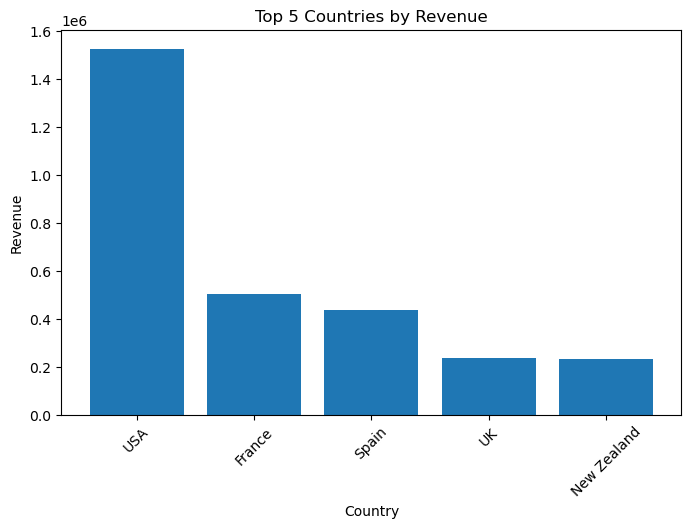

In [27]:
# bar
plt.figure(figsize=(8,5))
plt.bar(top5_countries.index, top5_countries["total_revenue"])

plt.title("Top 5 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

## 4. Conclusion

This notebook demonstrates a complete analytical ETL workflow for ClassicModels sales data.

The pipeline extracts order, product, customer, and currency data, transforms raw order-line records into revenue and profit metrics, creates summary tables by country and product line, and exports the final results to an Excel workbook.

The final Excel output can be used as a reporting layer for further analysis, dashboard preparation, or business review.